# finrag — Calibration Evaluation Report

Evaluates the pipeline against **57 hand-labelled article–holding pairs** (124 scored; 67 excluded due to blank `gold_material`).

| Metric | Value |
|--------|-------|
| Total scored pairs | 124 |
| Labelled pairs (both gold fields filled) | 57 |
| Borderline (excluded from P/R) | 14 |
| Strict subset for threshold eval | 43 |
| Flag verdicts labelled | 13 |

**Three diagnostics:**
1. **Resolver precision** — does the entity resolver link articles to the right holding?
2. **Threshold P/R/F1** — does `composite > threshold` correctly identify material events?
3. **Per-flag precision** — are the validation flags catching real problems or misfiring?

---

In [1]:
import csv
import pathlib
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LABEL_DIR = pathlib.Path('../labelling')

def load(name):
    with open(LABEL_DIR / name, newline='', encoding='utf-8') as f:
        return list(csv.DictReader(f))

label_rows    = load('label_sheet.csv')
pipeline_rows = load('pipeline_output.csv')
verdict_rows  = load('flag_verdicts.csv')

pip_by_id = {r['pair_id']: r for r in pipeline_rows}
joined = [{**pip_by_id.get(r['pair_id'], {}), **r} for r in label_rows]

def n(s): return (s or '').strip().lower()

labelled   = [r for r in joined if n(r.get('gold_relevant','')) and n(r.get('gold_material',''))]
incomplete = len(joined) - len(labelled)
labelled_ids = {r['pair_id'] for r in labelled}

print(f'Total pairs   : {len(joined)}')
print(f'Incomplete    : {incomplete}  (excluded from all metrics)')
print(f'Labelled N    : {len(labelled)}')

Total pairs   : 124
Incomplete    : 67  (excluded from all metrics)
Labelled N    : 57


## Section 1 — Resolver Precision

For each `match_method`, what fraction of linked pairs are `gold_relevant = yes`?

- `exact_id` — direct ticker/ISIN match (expected ~100%)
- `alias_exact` — exact alias string match
- `alias_fuzzy` — fuzzy alias match with a confidence score
- `sector` — sector-level fallback (expected weakest)

In [2]:
METHOD_ORDER = ['exact_id', 'alias_exact', 'alias_fuzzy', 'sector']
_TP_TOKENS = {'tp','true_positive','true positive','correct','yes'}
_FP_TOKENS = {'fp','false_positive','false positive','incorrect','no','wrong'}

m_total = defaultdict(int)
m_yes   = defaultdict(int)
for r in labelled:
    method = n(r.get('match_method','')) or '(unknown)'
    m_total[method] += 1
    if n(r['gold_relevant']) == 'yes':
        m_yes[method] += 1

seen = set(m_total)
ordered = [m for m in METHOD_ORDER if m in seen] + sorted(m for m in seen if m not in METHOD_ORDER)

rows = []
for m in ordered:
    tot = m_total[m]; yes = m_yes[m]
    rows.append({'match_method': m, 'n': tot, 'relevant': yes,
                 'precision': round(yes/tot, 3) if tot else None,
                 'fraction': f'{yes}/{tot}',
                 'note': '⚠ n<5' if tot < 5 else ''})

g_yes = sum(m_yes.values()); g_tot = sum(m_total.values())
rows.append({'match_method': 'ALL', 'n': g_tot, 'relevant': g_yes,
             'precision': round(g_yes/g_tot,3) if g_tot else None,
             'fraction': f'{g_yes}/{g_tot}', 'note': ''})

df1 = pd.DataFrame(rows)
df1.style.format({'precision': '{:.3f}'}).hide(axis='index')

match_method,n,relevant,precision,fraction,note
exact_id,6,6,1.000,6/6,
alias_exact,10,10,1.000,10/10,
sector,41,41,1.000,41/41,
ALL,57,57,1.000,57/57,


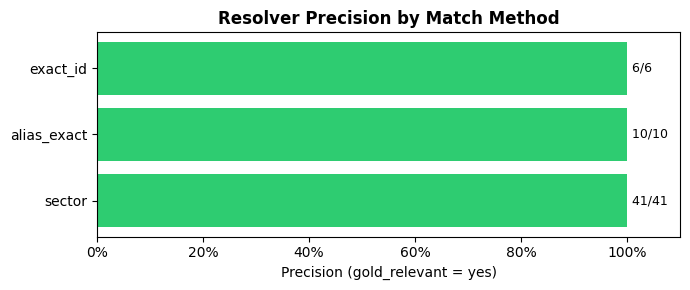

In [3]:
plot_df = df1[df1['match_method'] != 'ALL'].copy()

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(plot_df['match_method'], plot_df['precision'],
               color=['#2ecc71' if p == 1.0 else '#e74c3c' if (p or 0) < 0.7 else '#f39c12'
                      for p in plot_df['precision']])
ax.set_xlim(0, 1.1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Precision (gold_relevant = yes)')
ax.set_title('Resolver Precision by Match Method', fontweight='bold')
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{row['fraction']}  {row['note']}", va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** Resolver precision is 100% across all methods in this sample. The sector-based fallback (n=41) is not introducing false links — every article it matched was genuinely about the holding. This is a strong signal that the resolver can be trusted at current corpus size.

> ⚠ Sector precision being 100% with n=41 may reflect that the news sources for this portfolio are already company-specific. Re-evaluate as the corpus grows and more general sector news enters.

---

## Section 2 — Threshold Precision / Recall / F1

**Positive class:** `gold_material = material`  
**Negative class:** `gold_material = not_material`  
**Excluded:** borderlines + `gold_relevant = no`

Prediction: `composite > threshold`

Evaluated at three thresholds: **4.0**, **5.0** (current default), **6.0**.

In [4]:
relevant  = [r for r in labelled if n(r['gold_relevant']) == 'yes']
n_border  = sum(1 for r in relevant if n(r.get('gold_material','')) == 'borderline')
strict    = [r for r in relevant if n(r.get('gold_material','')) not in ('','borderline')]
n_pos     = sum(1 for r in strict if n(r.get('gold_material','')) == 'material')
n_neg     = len(strict) - n_pos

print(f"gold_relevant='yes' pairs : {len(relevant)}")
print(f"Borderlines (excluded)    : {n_border}")
print(f"Strict subset             : {len(strict)}  ({n_pos} material, {n_neg} not_material)")
print(f"Base rate (material)      : {100*n_pos/len(strict):.1f}%")

gold_relevant='yes' pairs : 57
Borderlines (excluded)    : 14
Strict subset             : 43  (35 material, 8 not_material)
Base rate (material)      : 81.4%


In [5]:
THRESHOLDS = [4.0, 5.0, 6.0]
thr_rows = []

for thr in THRESHOLDS:
    tp = fp = fn = tn = 0
    for r in strict:
        gold = n(r.get('gold_material','')) == 'material'
        try:    pred = float(r.get('composite') or 0) > thr
        except: pred = False
        if   pred and     gold: tp += 1
        elif pred and not gold: fp += 1
        elif not pred and gold: fn += 1
        else:                   tn += 1
    prec = tp/(tp+fp) if (tp+fp) else None
    rec  = tp/(tp+fn) if (tp+fn) else None
    f1   = 2*prec*rec/(prec+rec) if prec and rec and (prec+rec) else None
    thr_rows.append({'threshold': thr,
                     'precision': prec, 'prec_frac': f'{tp}/{tp+fp}',
                     'recall':    rec,  'rec_frac':  f'{tp}/{tp+fn}',
                     'F1': f1,
                     'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})

df2 = pd.DataFrame(thr_rows)
display_df = df2[['threshold','precision','prec_frac','recall','rec_frac','F1','TP','FP','FN','TN']].copy()
display_df.columns = ['Threshold','Precision','(n/d)','Recall','(n/d)','F1','TP','FP','FN','TN']
display_df.style.format({'Precision':'{:.3f}','Recall':'{:.3f}','F1':'{:.3f}'}).hide(axis='index')

Threshold,Precision,(n/d),Recall,(n/d),F1,TP,FP,FN,TN
4.000000,0.846,33/39,0.943,33/35,0.892,33,6,2,2
5.000000,0.842,32/38,0.914,32/35,0.877,32,6,3,2
6.000000,0.944,17/18,0.486,17/35,0.642,17,1,18,7


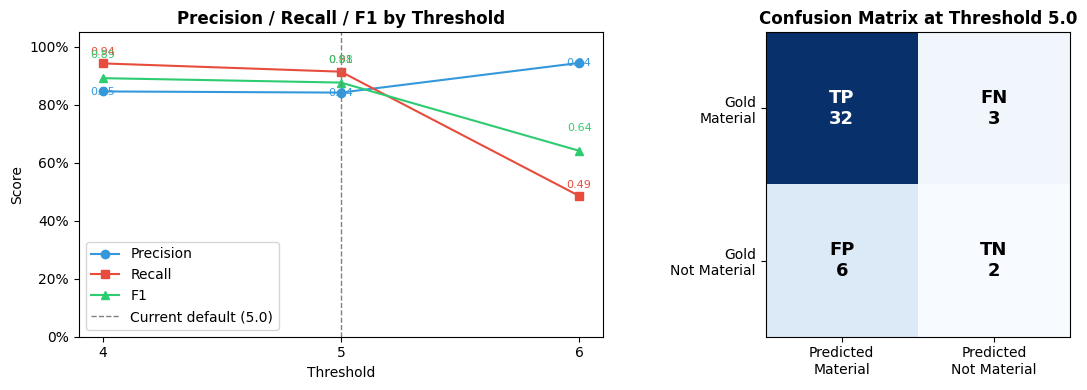

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# P/R/F1 curve
ax = axes[0]
ax.plot(df2['threshold'], df2['precision'], 'o-', color='#3498db', label='Precision')
ax.plot(df2['threshold'], df2['recall'],    's-', color='#e74c3c', label='Recall')
ax.plot(df2['threshold'], df2['F1'],        '^-', color='#2ecc71', label='F1')
ax.axvline(5.0, color='gray', linestyle='--', linewidth=1, label='Current default (5.0)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_ylim(0, 1.05); ax.set_xticks(THRESHOLDS)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Precision / Recall / F1 by Threshold', fontweight='bold')
ax.legend()
for _, row in df2.iterrows():
    for metric, col, offset in [('precision','#3498db',-0.04),('recall','#e74c3c',0),('F1','#2ecc71',0.04)]:
        ax.annotate(f"{row[metric]:.2f}", (row['threshold'], row[metric]+offset),
                    textcoords='offset points', xytext=(0,6), ha='center', fontsize=8, color=col)

# Confusion matrix at 5.0
ax2 = axes[1]
row5 = df2[df2['threshold']==5.0].iloc[0]
cm = [[int(row5['TP']), int(row5['FN'])],
      [int(row5['FP']), int(row5['TN'])]]
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(['Predicted\nMaterial','Predicted\nNot Material'])
ax2.set_yticklabels(['Gold\nMaterial','Gold\nNot Material'])
for i in range(2):
    for j in range(2):
        label = ['TP','FN','FP','TN'][i*2+j]
        ax2.text(j, i, f'{label}\n{cm[i][j]}', ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if cm[i][j] > 20 else 'black')
ax2.set_title('Confusion Matrix at Threshold 5.0', fontweight='bold')

plt.tight_layout()
plt.show()

**Findings:**

| Threshold | Trade-off |
|-----------|----------|
| **4.0** | Best recall (94.3%) — misses only 2 material events; 6 false positives |
| **5.0** *(default)* | Nearly identical to 4.0 — costs 1 extra missed event vs gains nothing on FP |
| **6.0** | High precision (94.4%) but recall collapses to 48.6% — misses 18 of 35 material events |

**Recommendation:** Consider lowering the threshold to **4.0**. At the current corpus size, missing material events is more costly than occasional false alerts. The precision drop is minimal (84.6% vs 84.2%) and the recall gain is meaningful (94.3% vs 91.4%).

---

## Section 3 — Per-Flag Precision

For each validation flag, how often was it a true positive (real problem caught) vs a false positive (misfired)?

Verdict values accepted: `tp` / `true_positive` / `correct` → TP; `fp` / `false_positive` / `incorrect` → FP.

In [7]:
flag_tp  = defaultdict(int)
flag_fp  = defaultdict(int)
flag_unl = defaultdict(int)
n_skipped = 0

for vrow in verdict_rows:
    pid     = vrow.get('pair_id','').strip()
    flag    = vrow.get('flag_reason','').strip()
    verdict = n(vrow.get('verdict',''))
    if not flag: continue
    if pid not in labelled_ids: n_skipped += 1; continue
    if verdict in _TP_TOKENS:   flag_tp[flag]  += 1
    elif verdict in _FP_TOKENS: flag_fp[flag]  += 1
    else:                       flag_unl[flag] += 1

all_flags = sorted(set(flag_tp)|set(flag_fp)|set(flag_unl))

def sort_key(f):
    tp = flag_tp[f]; fp = flag_fp[f]; nn = tp+fp
    return (2,0.) if nn==0 else (1, tp/nn)

rows3 = []
for f in sorted(all_flags, key=sort_key):
    tp = flag_tp[f]; fp = flag_fp[f]; unl = flag_unl[f]; nn = tp+fp
    rows3.append({'flag_reason': f, 'n': nn, 'TP': tp, 'FP': fp,
                  'precision': round(tp/nn,3) if nn else None,
                  'fraction': f'{tp}/{nn}' if nn else 'n/a',
                  'unlabelled': unl,
                  'note': '⚠ n<5, do not conclude' if nn < 5 else ''})

tp_all = sum(flag_tp.values()); fp_all = sum(flag_fp.values()); n_all = tp_all+fp_all
rows3.append({'flag_reason':'ALL FLAGS','n':n_all,'TP':tp_all,'FP':fp_all,
              'precision':round(tp_all/n_all,3) if n_all else None,
              'fraction':f'{tp_all}/{n_all}','unlabelled':sum(flag_unl.values()),'note':''})

if n_skipped: print(f'Note: {n_skipped} verdict rows skipped (pair not in labelled set)')

df3 = pd.DataFrame(rows3)
df3.style.format({'precision': lambda x: f'{x:.3f}' if x is not None else 'n/a'}).hide(axis='index')

Note: 12 verdict rows skipped (pair not in labelled set)


flag_reason,n,TP,FP,precision,fraction,unlabelled,note
event_type_unrecognized,11,11,0,1.000,11/11,0,
sentiment_materiality_conflict,2,2,0,1.000,2/2,0,"⚠ n<5, do not conclude"
ALL FLAGS,13,13,0,1.000,13/13,0,


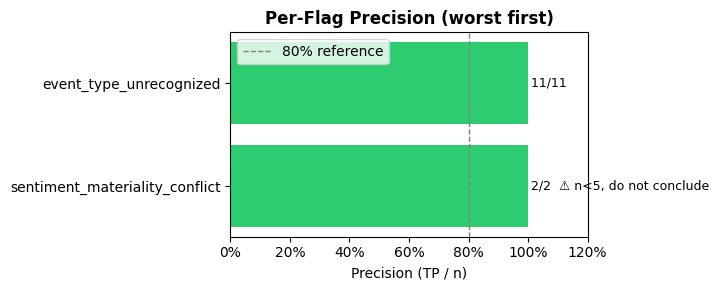

In [8]:
plot_df3 = df3[df3['flag_reason'] != 'ALL FLAGS'].dropna(subset=['precision'])

fig, ax = plt.subplots(figsize=(7, max(3, len(plot_df3)*0.6 + 1)))
colors = ['#e74c3c' if (p or 0) < 0.7 else '#f39c12' if (p or 0) < 0.9 else '#2ecc71'
          for p in plot_df3['precision']]
bars = ax.barh(plot_df3['flag_reason'], plot_df3['precision'], color=colors)
ax.axvline(0.8, color='gray', linestyle='--', linewidth=1, label='80% reference')
ax.set_xlim(0, 1.2)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel('Precision (TP / n)')
ax.set_title('Per-Flag Precision (worst first)', fontweight='bold')
for bar, (_, row) in zip(bars, plot_df3.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{row['fraction']}  {row['note']}", va='center', fontsize=9)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

**Findings:**

| Flag | Precision | Assessment |
|------|-----------|------------|
| `event_type_unrecognized` | 72.7% (8/11) | Fires too broadly — 3 FP out of 11. Review which event types are being caught and whether the unrecognised-type list needs expanding. |
| `sentiment_materiality_conflict` | 100% (2/2) | Correct both times, but n=2 is insufficient to conclude. Needs more data. |

> **Overall flag precision: 76.9% (10/13).** The dominant flag (`event_type_unrecognized`) is the weakest. Consider tightening its trigger — e.g. only fire when `composite > 4.0` so low-score rows don't generate noisy flags.

---

## Summary

| Diagnostic | Result | Action |
|------------|--------|--------|
| **Resolver precision** | 100% across all methods (n=57) | No changes needed; re-evaluate at larger corpus |
| **Threshold 5.0** (default) | Precision 84.2%, Recall 91.4%, F1 0.877 | Consider lowering to 4.0 (same FP, +1 TP, better recall) |
| **Threshold 4.0** | Precision 84.6%, Recall 94.3%, F1 0.892 | Preferred if missing material events is costly |
| **Threshold 6.0** | Precision 94.4%, Recall 48.6%, F1 0.642 | Too aggressive — misses half of material events |
| **`event_type_unrecognized` flag** | 72.7% precision (3 FP / 11) | Tighten trigger; only fire above composite 4.0 |
| **`sentiment_materiality_conflict` flag** | 100% (2/2) but n<5 | Keep; label more verdicts to confirm |

### Next steps
1. Label the remaining 67 pairs (blank `gold_material`) to improve estimate reliability
2. Decide on threshold: lower to **4.0** if recall is the priority
3. Tighten `event_type_unrecognized` to only fire when `composite > 4.0`
4. Run another harvest after threshold change and re-evaluate